# Single Qubit Gates

In [28]:
import numpy as np
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_aer import QasmSimulator

## Visualization of quantum circuit

In [6]:
def qplot(x):
    '''
    x : is a qauntum circuit
    '''
    return x.draw(fold = False, initial_state = True, scale = 0.8)

## Pauli Gates
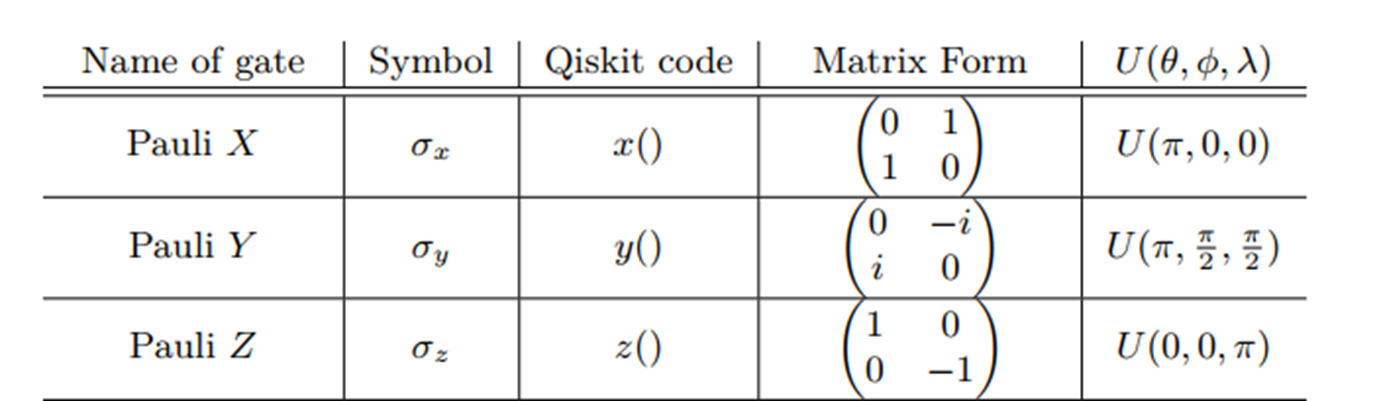

In [16]:
q = QuantumRegister(1, 'qubit')
c = ClassicalRegister(1, 'bit')

qc = QuantumCircuit(q, c)
qc.x(q)
qc.y(q)
qc.z(q)

display(qplot(qc), Statevector(qc).draw('latex'))

┌───┐┌───┐
qubit: |0>┤ X ├┤ Z ├
          └───┘└───┘
 bit: 0 1/══════════

<IPython.core.display.Latex object>

## Hadamard Gate

In [21]:
qc = QuantumCircuit(q,c)
qc.x(q)
qc.h(q)


display(qplot(qc), Statevector(qc).draw('latex'))

┌───┐┌───┐
qubit: |0>┤ X ├┤ H ├
          └───┘└───┘
 bit: 0 1/══════════

<IPython.core.display.Latex object>

## Rotation Gates
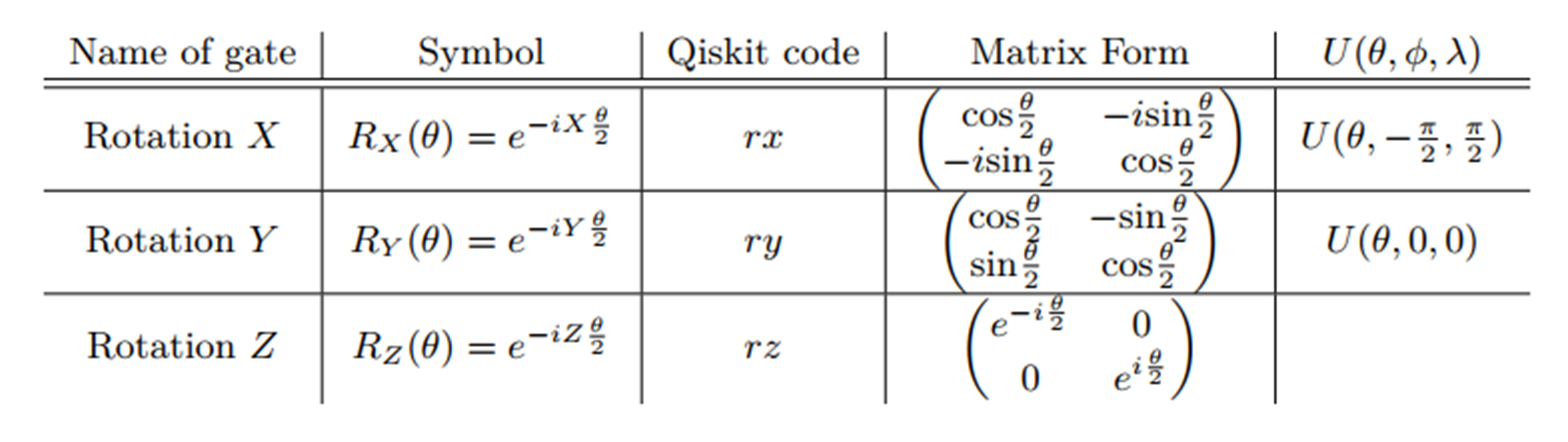

In [26]:
qc = QuantumCircuit(q,c)
qc.rx(np.pi, q)
qc.ry(np.pi/4, q)
qc.rz(np.pi/7, q)


display(qplot(qc), Statevector(qc).draw('latex'))

┌───────┐┌─────────┐┌─────────┐
qubit: |0>┤ Rx(π) ├┤ Ry(π/4) ├┤ Rz(π/7) ├
          └───────┘└─────────┘└─────────┘
 bit: 0 1/═══════════════════════════════

<IPython.core.display.Latex object>

In [30]:
qc.measure(q, c)
qplot(qc)

┌───────┐┌─────────┐┌─────────┐┌─┐
qubit: |0>┤ Rx(π) ├┤ Ry(π/4) ├┤ Rz(π/7) ├┤M├
          └───────┘└─────────┘└─────────┘└╥┘
 bit: 0 1/════════════════════════════════╩═
                                          0

In [31]:
backend = QasmSimulator()
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc)
result = job.result()
counts = result.get_counts()
counts

{'0': 143, '1': 881}

## Phase Gate
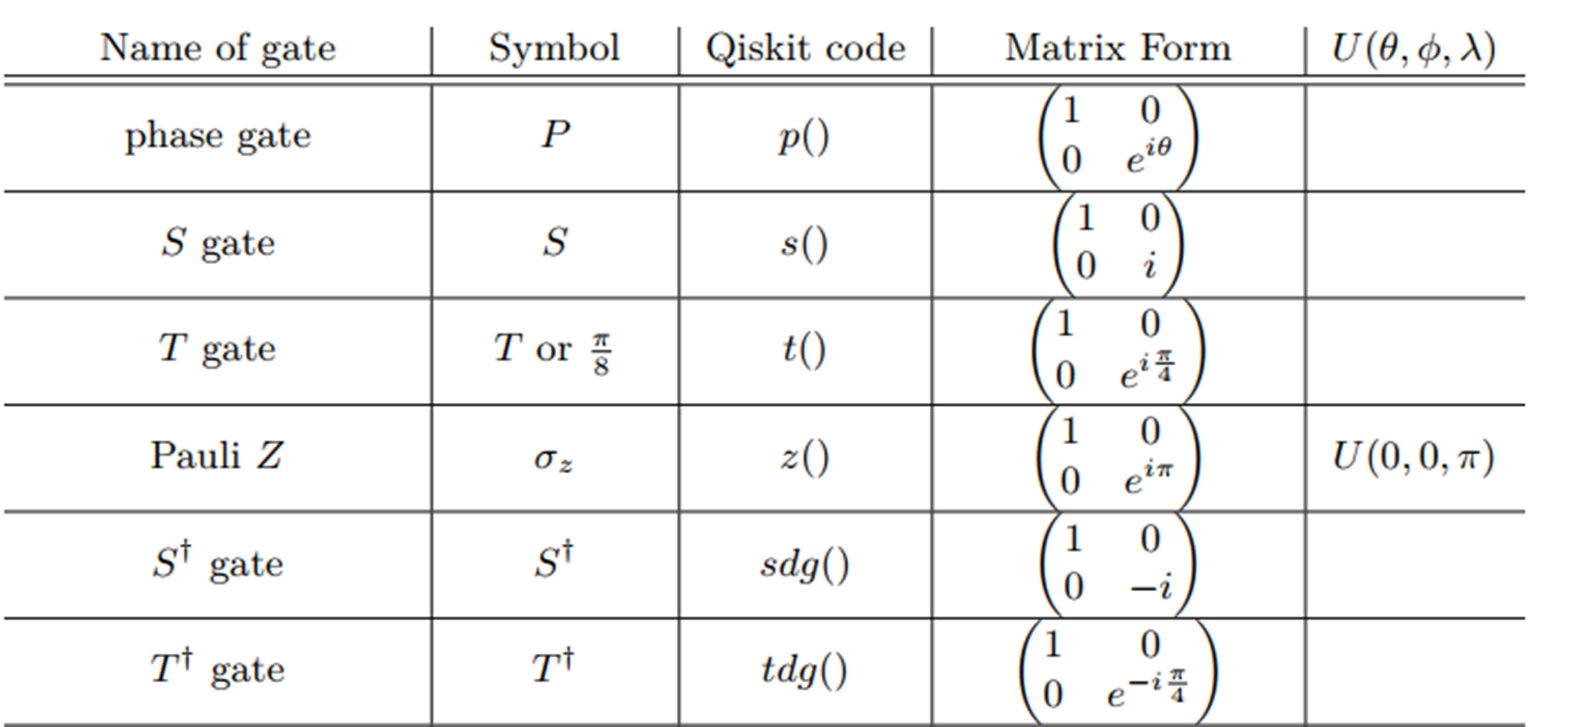

In [41]:
qc = QuantumCircuit(q,c)
qc.x(q)
qc.p(np.pi/2, q)
qc.s(q)
qc.t(q)
qc.sdg(q)
#qc.tdg(q)

display(qplot(qc), Statevector(qc).draw('latex'))

┌───┐┌────────┐┌───┐┌───┐┌─────┐
qubit: |0>┤ X ├┤ P(π/2) ├┤ S ├┤ T ├┤ Sdg ├
          └───┘└────────┘└───┘└───┘└─────┘
 bit: 0 1/════════════════════════════════

<IPython.core.display.Latex object>

In [43]:
qc.measure(q,c)

In [44]:
backend = QasmSimulator()
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc)
result = job.result()
counts = result.get_counts()
counts

{'1': 1024}